In [69]:
!pip install -q kaggle

In [70]:
import kagglehub

path = kagglehub.dataset_download("aniruddhsharma/structural-defects-network-concrete-crack-images")

print(path)

/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images


In [71]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Directories:", dirs)
    print("Files:", files[:5])  # Show first 5 files
    print("-" * 50)

/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images
Directories: ['Pavements', 'Decks', 'Walls']
Files: []
--------------------------------------------------
/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/Pavements
Directories: ['Non-cracked', 'Cracked']
Files: []
--------------------------------------------------
/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/Pavements/Non-cracked
Directories: []
Files: ['081-47.jpg', '017-208.jpg', '047-154.jpg', '052-173.jpg', '006-229.jpg']
--------------------------------------------------
/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/Pavements/Cracked
Directories: []
Files: ['095-79.jpg', '100-92.jpg', '018-69.jpg', '099-101.jpg', '094-101.jpg']
--------------------------------------------------
/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/Decks
Direct

In [72]:
import os

decks_dir = "/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/Decks"

class_counts = {}
for cls in ["Cracked", "Non-cracked"]:
    folder = os.path.join(decks_dir, cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(files)

total = sum(class_counts.values())
for cls, count in class_counts.items():
    print(f"{cls}: {count} images ({count/total:.1%})")

imbalance_ratio = max(class_counts.values()) / min(class_counts.values())
print(f"\nImbalance ratio (majority:minority): {imbalance_ratio:.2f} : 1")

Cracked: 2025 images (14.9%)
Non-cracked: 11595 images (85.1%)

Imbalance ratio (majority:minority): 5.73 : 1


In [73]:
import re

cracked_files = os.listdir(os.path.join(decks_dir, "Cracked"))
panel_ids = set(re.match(r'^(\d+)-', f).group(1) for f in cracked_files if re.match(r'^(\d+)-', f))
print(f"Unique source panels in Cracked class: {len(panel_ids)}")

Unique source panels in Cracked class: 54


In [74]:
import os, re
import pandas as pd

decks_dir = "/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/Decks"

records = []
for cls in ["Cracked", "Non-cracked"]:
    folder = os.path.join(decks_dir, cls)
    for f in os.listdir(folder):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            m = re.match(r'^(\d+)-', f)
            panel_id = m.group(1) if m else "unknown"
            records.append({"filename": f, "class": cls, "panel_id": panel_id,
                             "filepath": os.path.join(folder, f)})

df = pd.DataFrame(records)
print(f"Total unique panels across both classes: {df['panel_id'].nunique()}")
shared = df.groupby("panel_id")["class"].nunique()
print(f"Panels containing BOTH classes: {(shared > 1).sum()} out of {len(shared)}")

Total unique panels across both classes: 54
Panels containing BOTH classes: 54 out of 54


In [75]:
import os, re, shutil
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

SEED = 42
decks_dir = "/kaggle/input/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/Decks"
class_dirs = {
    "Cracked": os.path.join(decks_dir, "Cracked"),
    "Non-cracked": os.path.join(decks_dir, "Non-cracked"),
}

# Build one dataframe across both classes, with panel_id extracted per file
records = []
for cls, folder in class_dirs.items():
    for f in os.listdir(folder):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            m = re.match(r'^(\d+)-', f)
            panel_id = m.group(1) if m else "unknown"
            records.append({"filename": f, "class": cls, "panel_id": panel_id,
                             "filepath": os.path.join(folder, f)})
df = pd.DataFrame(records)

# Group split by panel_id — NOT train_test_split on individual files
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(df, groups=df["panel_id"]))
train_df, temp_df = df.iloc[train_idx], df.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["panel_id"]))
val_df, test_df = temp_df.iloc[val_idx], temp_df.iloc[test_idx]

assert set(train_df.panel_id) & set(val_df.panel_id) == set()
assert set(train_df.panel_id) & set(test_df.panel_id) == set()
assert set(val_df.panel_id) & set(test_df.panel_id) == set()

# Rebuild output directory from scratch — same habit as the tomato project
base_out = "/kaggle/working/crack_split"
if os.path.exists(base_out):
    shutil.rmtree(base_out)
for split in ['train', 'validation', 'test']:
    for cls in class_dirs:
        os.makedirs(os.path.join(base_out, split, cls), exist_ok=True)

for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    for _, row in split_df.iterrows():
        shutil.copy(row['filepath'], os.path.join(base_out, split_name, row['class'], row['filename']))
    counts = split_df['class'].value_counts()
    print(f"{split_name}: {dict(counts)}  ratio={counts.max()/counts.min():.2f}:1  panels={split_df['panel_id'].nunique()}")

train_dir = os.path.join(base_out, 'train')
val_dir   = os.path.join(base_out, 'validation')
test_dir  = os.path.join(base_out, 'test')

train: {'Non-cracked': np.int64(7954), 'Cracked': np.int64(1382)}  ratio=5.76:1  panels=37
validation: {'Non-cracked': np.int64(1706), 'Cracked': np.int64(310)}  ratio=5.50:1  panels=8
test: {'Non-cracked': np.int64(1935), 'Cracked': np.int64(333)}  ratio=5.81:1  panels=9


In [76]:
# Imports + reproducibility

import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version: {tf.__version__}')

results_dir = "results/Deck Crack Detection/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs('models', exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}' if gpus else 'No GPU — training on CPU (slower).')

TensorFlow version: 2.20.0
GPUs available: 2


In [77]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

In [78]:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
    label_mode='binary',
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

class_names = train_dataset.class_names
print(f'Classes: {class_names}')  # confirm this prints exactly ['Cracked', 'Non-cracked']

Found 9336 files belonging to 2 classes.
Found 2016 files belonging to 2 classes.
Found 2268 files belonging to 2 classes.
Classes: ['Cracked', 'Non-cracked']


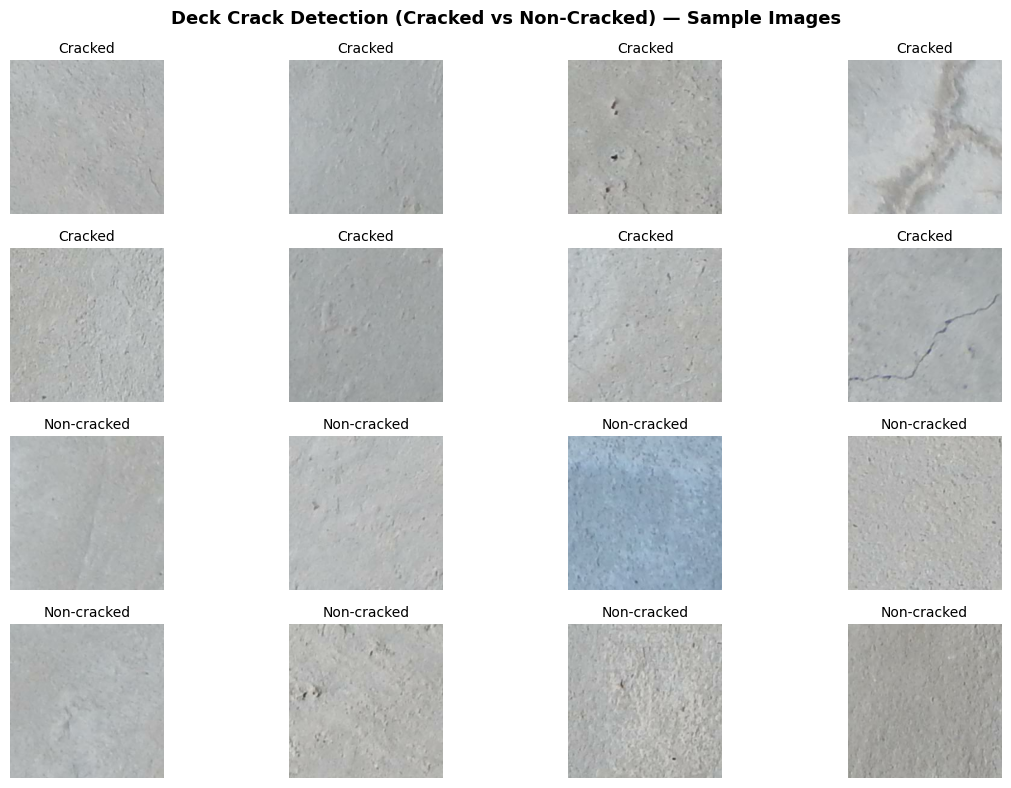

In [79]:
# Pull batches until we have at least a few of each class to actually inspect

results_dir = "results/crack_deck_lab/"
os.makedirs(results_dir, exist_ok=True)

collected_images, collected_labels = [], []
for images, labels in train_dataset.take(10):  # look through up to 10 batches
    collected_images.append(images.numpy())
    collected_labels.append(labels.numpy())
    all_labels = np.concatenate(collected_labels).flatten()
    if (all_labels == 0).sum() >= 8 and (all_labels == 1).sum() >= 8:
        break

fixed_images = np.concatenate(collected_images)
fixed_labels = np.concatenate(collected_labels)

cracked_idx = np.where(fixed_labels.flatten() == 0)[0][:8]      # adjust index if class_names order differs
noncracked_idx = np.where(fixed_labels.flatten() == 1)[0][:8]
show_idx = np.concatenate([cracked_idx, noncracked_idx])

plt.figure(figsize=(12, 8))
for i, idx in enumerate(show_idx):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[idx].astype('uint8'))
    label_idx = int(fixed_labels[idx][0])
    plt.title(class_names[label_idx], fontsize=10)
    plt.axis('off')
plt.suptitle('Deck Crack Detection (Cracked vs Non-Cracked) — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [80]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels = np.array([int(y.numpy()) for _, y in train_dataset.unbatch()])
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))
print("Class distribution weights:", class_weight_dict)
print("Label counts:", np.bincount(train_labels))

/tmp/ipykernel_58/1819620257.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  train_labels = np.array([int(y.numpy()) for _, y in train_dataset.unbatch()])


Class distribution weights: {0: np.float64(3.377713458755427), 1: np.float64(0.5868745285390998)}
Label counts: [1382 7954]


In [81]:
#  Pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [84]:
# Flip labels right after loading, BEFORE caching/augmentation:
# after this, label 1 = Cracked, label 0 = Non-cracked
def flip_label(image, label):
    return image, 1.0 - label

train_dataset = train_dataset.map(flip_label)
val_dataset   = val_dataset.map(flip_label)
test_dataset  = test_dataset.map(flip_label)

class_names_eval = ['Non-cracked', 'Cracked']  # matches new 0/1 order — use this everywhere downstream, not the old class_names

# Recompute class weights AFTER the flip, not before — they must reflect flipped labels
train_labels = np.array([int(y.numpy()) for _, y in train_dataset.unbatch()])
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))
print("Weights (0=Non-cracked, 1=Cracked):", class_weight_dict)


/tmp/ipykernel_58/2861716757.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  train_labels = np.array([int(y.numpy()) for _, y in train_dataset.unbatch()])


Weights (0=Non-cracked, 1=Cracked): {0: np.float64(3.377713458755427), 1: np.float64(0.5868745285390998)}


In [88]:
#  Augmentation
# augment dataset to contain rotated_by_X / translation / flip / saltandpepper copies
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

<Figure size 1200x800 with 0 Axes>

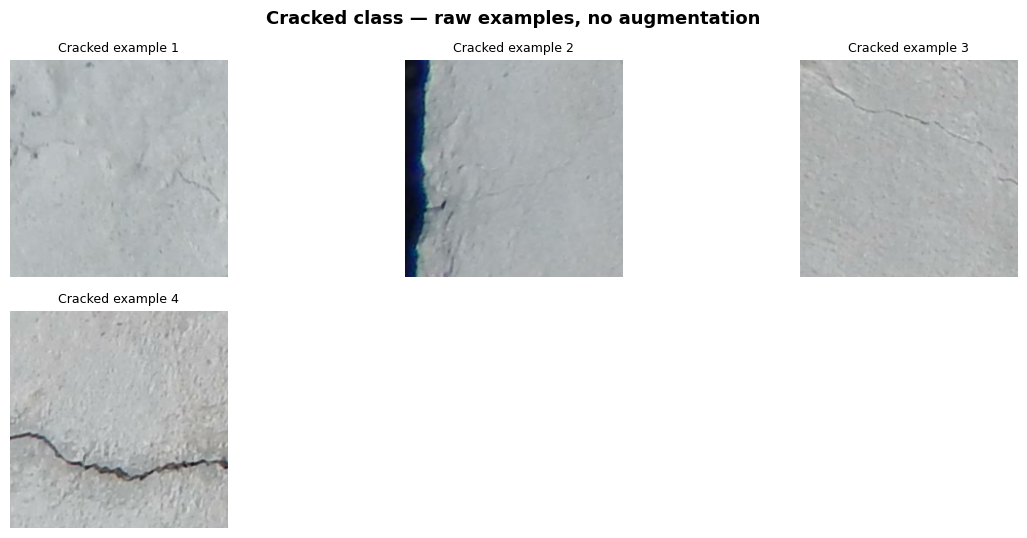

In [89]:
# Visualize what augmentation actually does to a real training image
for images, labels in train_dataset.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

plt.figure(figsize=(12, 8))
# Pull several distinct cracked source images (not augmented copies) and eyeball crack size/position
cracked_batch_pos = np.where(sample_labels.flatten() == 0)[0][:9]
plt.figure(figsize=(12, 8))
for i, idx in enumerate(cracked_batch_pos):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[idx].astype('uint8'))
    plt.title(f'Cracked example {i+1}', fontsize=9)
    plt.axis('off')
plt.suptitle('Cracked class — raw examples, no augmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



<Figure size 1200x800 with 0 Axes>

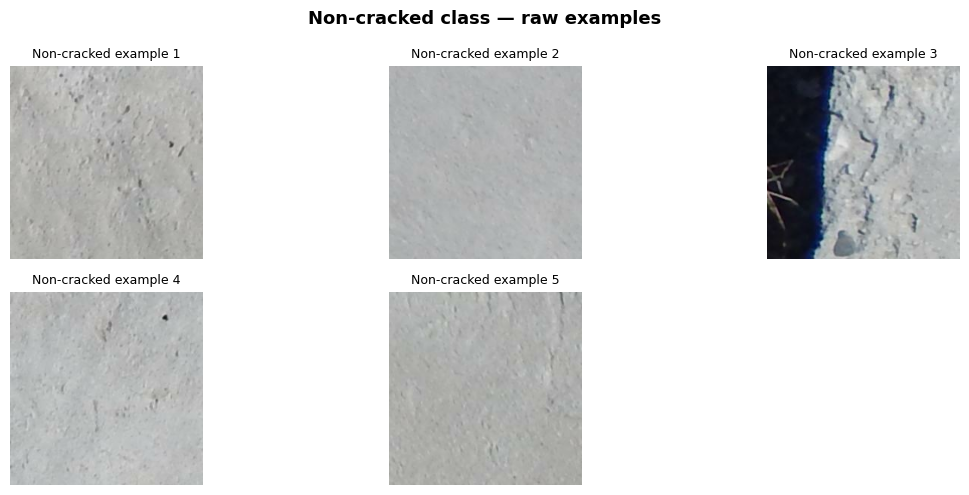

In [90]:
# Visualize what augmentation actually does to a real training image
for images, labels in train_dataset.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

plt.figure(figsize=(12, 8))
# Pull several distinct cracked source images (not augmented copies) and eyeball crack size/position
noncracked_batch_pos = np.where(sample_labels.flatten() == 1)[0][:5]  # confirm 1 = Non-cracked
plt.figure(figsize=(12, 5))
for i, idx in enumerate(noncracked_batch_pos):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[idx].astype('uint8'))
    plt.title(f'Non-cracked example {i+1}', fontsize=9)
    plt.axis('off')
plt.suptitle('Non-cracked class — raw examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [101]:

def make_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_recall', mode='max', save_best_only=True,
        ),
        
        tf.keras.callbacks.EarlyStopping(
           monitor='val_recall', mode='max', patience=8,
           restore_best_weights=True, verbose=1,
       ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()
    return {'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob, 'accuracy': accuracy_score(y_true, y_pred)}

In [103]:
def build_transfer_model(input_shape, augmentation, base_trainable=False):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base_model.trainable = base_trainable

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='efficientnet_transfer')

cnn_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [104]:
from tensorflow.keras.metrics import Precision, Recall, AUC

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')],
)

cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset, epochs=EPOCHS,
    callbacks=make_callbacks('efficientnet_transfer'), verbose=1,
    class_weight=class_weight_dict,
)

Epoch 1/50


E0000 00:00:1785402380.654466      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnet_transfer_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


292/292 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.7113 - auc: 0.7252 - loss: 0.5983 - precision: 0.9116 - recall: 0.7322 - val_accuracy: 0.8001 - val_auc: 0.8149 - val_loss: 0.5170 - val_precision: 0.9295 - val_recall: 0.8265 - learning_rate: 0.0010
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.7825 - auc: 0.8070 - loss: 0.5250 - precision: 0.9315 - recall: 0.8037 - val_accuracy: 0.8591 - val_auc: 0.8292 - val_loss: 0.4308 - val_precision: 0.9232 - val_recall: 0.9091 - learning_rate: 0.0010
Epoch 3/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.7934 - auc: 0.8159 - loss: 0.5098 - precision: 0.9319 - recall: 0.8172 - val_accuracy: 0.8710 - val_auc: 0.8366 - val_loss: 0.4056 - val_precision: 0.9208 - val_recall: 0.9273 - learning_rate: 0.0010
Epoch 4/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 86ms/step - accuracy: 0.7903 - auc: 0.8132 - loss: 0.5095 - precision: 0.9334 - recall: 0.8118 - val_accuracy: 0.8497 - val_auc: 0.8412 - val_loss: 0.4456 - val_pr

Validation — loss: 0.3541, accuracy: 0.8869, precision: 0.9208, recall: 0.9478, auc: 0.8395


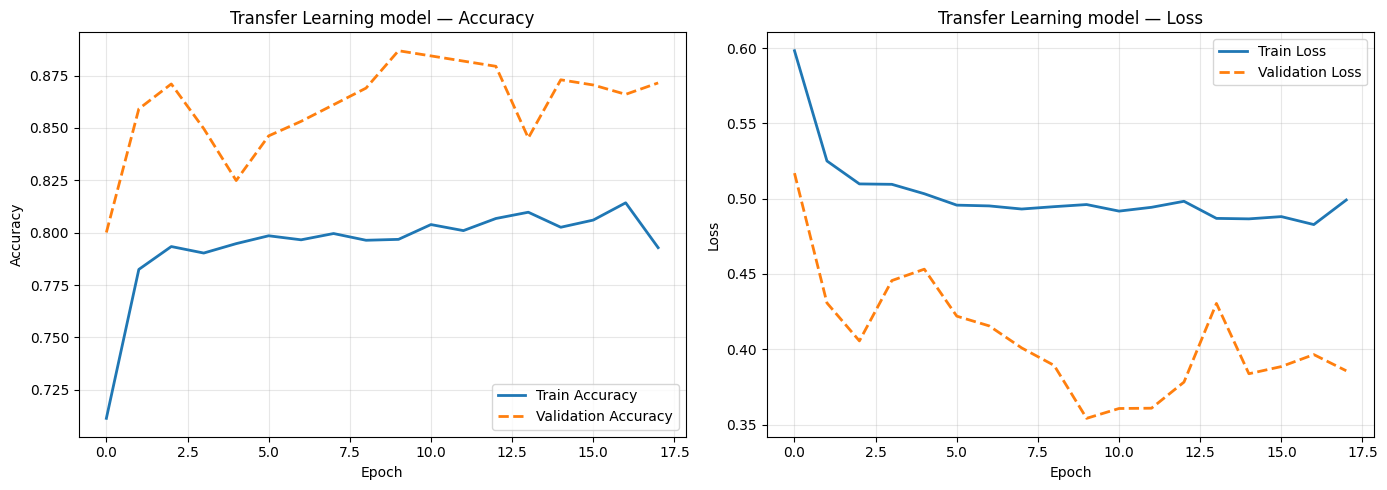

2026-07-30 09:14:31.167658: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Custom CNN
Accuracy : 0.9039
Precision: 0.9446
Recall   : 0.9426
F1-Score : 0.9436

Classification Report:
              precision    recall  f1-score   support

     Cracked     0.6706    0.6787    0.6746       333
 Non-cracked     0.9446    0.9426    0.9436      1935

    accuracy                         0.9039      2268
   macro avg     0.8076    0.8107    0.8091      2268
weighted avg     0.9044    0.9039    0.9041      2268



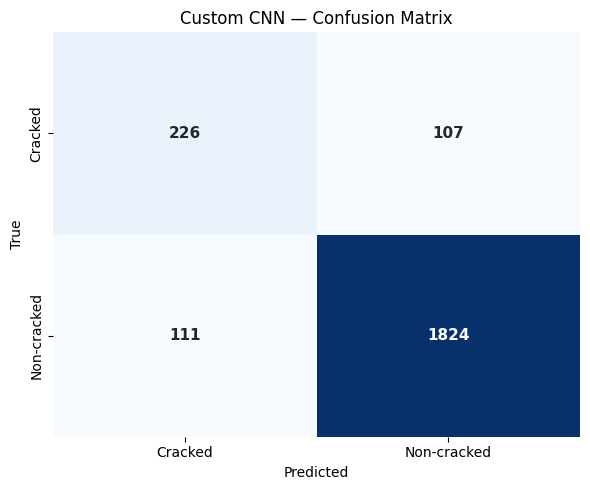

In [105]:
# STEP: Evaluate
val_results = cnn_model.evaluate(val_dataset, verbose=0, return_dict=True)
print(f"Validation — loss: {val_results['loss']:.4f}, accuracy: {val_results['accuracy']:.4f}, "
      f"precision: {val_results['precision']:.4f}, recall: {val_results['recall']:.4f}, auc: {val_results['auc']:.4f}")

plot_learning_curves(cnn_history, 'Transfer Learning model')
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')